
###Cross-Channel Marketing Optimization: Facebook vs Google AdWords

Objective:
Evaluate and compare the performance and efficiency of Facebook Ads and Google AdWords
to determine which platform delivers better Conversion Rate (CR) and Cost Per Acquisition (CPA).

Goal:
Provide data-driven recommendations for budget allocation, funnel optimization, and campaign scaling.

Approach:
- Structured EDA (Trend, Segmentation, Deviation, Distribution, Correlation)
- Statistical testing
- Confidence Intervals for Mean Differences
- Predictive Modeling & Assumption Validation


###Imports & Setup

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Load Data

In [113]:
df = pd.read_csv('/content/drive/MyDrive/Marketing Channel data/marketing_campaign.csv')

In [114]:
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,1/1/2019,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30
1,1/2/2019,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05
2,1/3/2019,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23
3,1/4/2019,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86
4,1/5/2019,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40


In [115]:
df.shape

(365, 17)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             365 non-null    object
 1   Facebook Ad Campaign                             365 non-null    object
 2   Facebook Ad Views                                365 non-null    int64 
 3   Facebook Ad Clicks                               365 non-null    int64 
 4   Facebook Ad Conversions                          365 non-null    int64 
 5   Cost per Facebook Ad                             365 non-null    object
 6   Facebook Click-Through Rate (Clicks / View)      365 non-null    object
 7   Facebook Conversion Rate (Conversions / Clicks)  365 non-null    object
 8   Facebook Cost per Click (Ad Cost / Clicks)       365 non-null    object
 9   AdWords Ad Campaign                        

###Data Cleaning

In [117]:
#change the date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


##clean_percentage and clean_currency

# Strip %, convert to float
def clean_percentage(col):
    return col.astype(str).str.replace('%', '').astype(float)

# Strip $, convert to float
def clean_currency(col):
    return col.astype(str).str.replace('$', '').astype(float)


# Facebook
df['FB_CTR_raw'] = clean_percentage(df['Facebook Click-Through Rate (Clicks / View)'])
df['FB_CR_raw'] = clean_percentage(df['Facebook Conversion Rate (Conversions / Clicks)'])
df['FB_Cost_Per_Click'] = clean_currency(df['Facebook Cost per Click (Ad Cost / Clicks)'])
df['FB_Total_Cost'] = clean_currency(df['Cost per Facebook Ad'])

# AdWords
df['AW_CTR_raw'] = clean_percentage(df['AdWords Click-Through Rate (Clicks / View)'])
df['AW_CR_raw'] = clean_percentage(df['AdWords Conversion Rate (Conversions / Click)'])
df['AW_Cost_Per_Click'] = clean_currency(df['AdWords Cost per Click (Ad Cost / Clicks)'])
df['AW_Total_Cost'] = clean_currency(df['Cost per AdWords Ad'])


###Feature Engineering

In [118]:

#Calculated Metrics Derivation
def safe_divide(a, b):
    return np.where(b == 0, 0, a / b)

df['FB_CR_calc'] = safe_divide(df['Facebook Ad Conversions'], df['Facebook Ad Clicks'])
df['AW_CR_calc'] = safe_divide(df['AdWords Ad Conversions'], df['AdWords Ad Clicks'])

df['FB_CPA'] = safe_divide(df['FB_Total_Cost'], df['Facebook Ad Conversions'])
df['AW_CPA'] = safe_divide(df['AW_Total_Cost'], df['AdWords Ad Conversions'])

df['month'] = df['Date'].dt.month
df['weekday'] = df['Date'].dt.day_name()

#### Exploratory Data Analysis

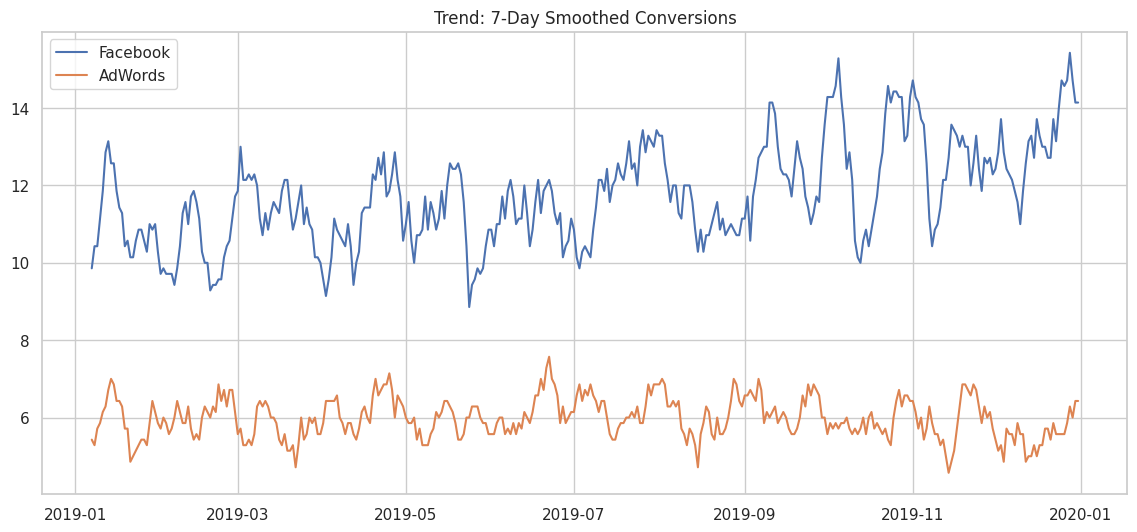

In [119]:
#Trend Analysis
plt.figure(figsize=(14,6))

df['FB_7d'] = df['Facebook Ad Conversions'].rolling(7).mean()
df['AW_7d'] = df['AdWords Ad Conversions'].rolling(7).mean()

plt.plot(df['Date'], df['FB_7d'], label='Facebook')
plt.plot(df['Date'], df['AW_7d'], label='AdWords')

plt.title("Trend: 7-Day Smoothed Conversions")
plt.legend()
plt.show()

### Observation on Trend Analysis
Facebook shows a clear upward trend starting around August 2019, hitting its peak near the end of the year.

AdWords remains relatively stagnant, hovering around a mean of 6 conversions with no significant growth over the 12-month period.

Facebook shows much higher variance (wider swings) than AdWords. This suggests Facebook's performance might be more sensitive to specific campaign changes or seasonal spikes.

Facebook Segmentation:
 FB_segment
Medium    145
Low       129
High       91
Name: count, dtype: int64

AdWords Segmentation:
 AW_segment
Low       156
Medium    137
High       72
Name: count, dtype: int64


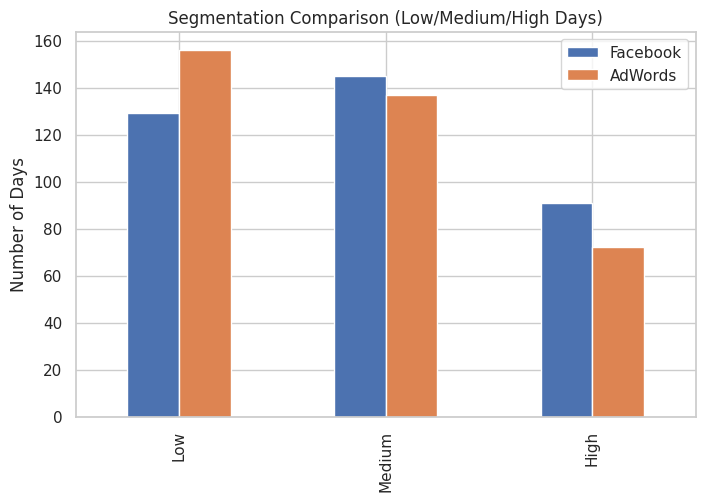

In [120]:
#Segmentation Analysis

df['FB_segment'] = pd.qcut(
    df['Facebook Ad Conversions'],
    q=3,
    labels=['Low','Medium','High']
)

df['AW_segment'] = pd.qcut(
    df['AdWords Ad Conversions'],
    q=3,
    labels=['Low','Medium','High']
)

print("Facebook Segmentation:\n", df['FB_segment'].value_counts())
print("\nAdWords Segmentation:\n", df['AW_segment'].value_counts())

#Comparison Visualization
seg_compare = pd.DataFrame({
    'Facebook': df['FB_segment'].value_counts(),
    'AdWords': df['AW_segment'].value_counts()
})

seg_compare.plot(kind='bar', figsize=(8,5))
plt.title("Segmentation Comparison (Low/Medium/High Days)")
plt.ylabel("Number of Days")
plt.show()

### Observations:
Facebook Distribution: Your segments are relatively balanced ($145, 129, 91$). The fact that "Medium" is the largest group suggests a "Normal" or "Bell Curve" style distribution where most days fall into a middle performance tier.


AdWords Distribution: AdWords is heavily skewed toward "Low" days ($156$). Since qcut tries to make bins equal, the fact that they aren't perfectly equal ($156$ vs $72$) usually indicates many duplicate values (e.g., many days with exactly 0 or 1 conversion), forcing the "Low" bin to swell.

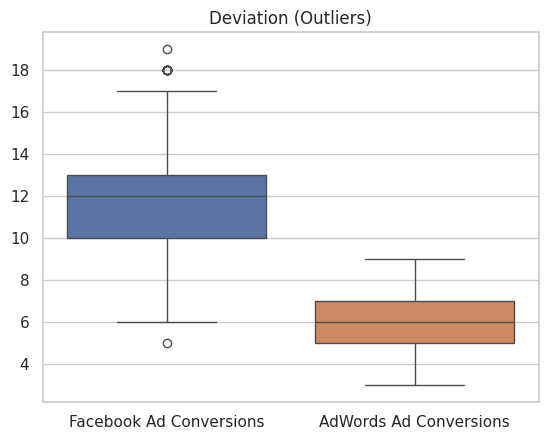

In [121]:
# Deviation ANalsys
sns.boxplot(data=df[['Facebook Ad Conversions','AdWords Ad Conversions']])
plt.title("Deviation (Outliers)")
plt.show()

### Observations

The Facebook box is significantly taller than the AdWords box, confirming that Facebook has a higher standard deviation and less predictable daily performance.

Outlier Detection: * Facebook has clear high-end outliers (above 18 conversions), representing "viral" or exceptional performance days. It also has a low-end outlier (near 5).

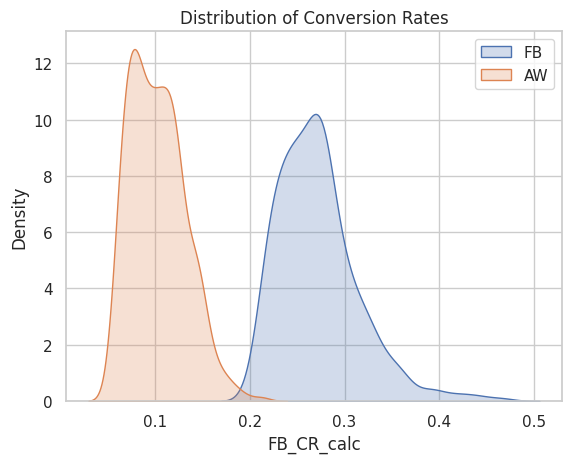

In [122]:
#Distribution

sns.kdeplot(df['FB_CR_calc'], label='FB', fill=True)
sns.kdeplot(df['AW_CR_calc'], label='AW', fill=True)
plt.legend()
plt.title("Distribution of Conversion Rates")
plt.show()

### Observations

Facebook curve has a "tail" stretching toward $0.5$ (50%). This confirms what we saw in the boxplot—Facebook has a higher potential for "extraordinary" performance days, whereas AdWords is tightly clustered around a lower average.

Facebook isn't just getting more conversions; it is converting users at a much higher rate per click.

In [123]:
#Correlation Analysis

# Facebook correlation
fb_corr = df[['Facebook Ad Clicks', 'Facebook Ad Conversions',
    'FB_Total_Cost', 'FB_CTR_raw', 'FB_CPA', 'month']].corr()

# AdWords correlation
aw_corr = df[['AdWords Ad Clicks', 'AdWords Ad Conversions',
    'AW_Total_Cost', 'AW_CTR_raw', 'AW_CPA', 'month']].corr()

print("Facebook Correlation:\n", fb_corr)
print("\nAdWords Correlation:\n", aw_corr)

Facebook Correlation:
                          Facebook Ad Clicks  Facebook Ad Conversions  \
Facebook Ad Clicks                 1.000000                 0.873775   
Facebook Ad Conversions            0.873775                 1.000000   
FB_Total_Cost                     -0.054901                -0.125413   
FB_CTR_raw                         0.613940                 0.526807   
FB_CPA                            -0.555316                -0.671891   
month                              0.353172                 0.268098   

                         FB_Total_Cost  FB_CTR_raw    FB_CPA     month  
Facebook Ad Clicks           -0.054901    0.613940 -0.555316  0.353172  
Facebook Ad Conversions      -0.125413    0.526807 -0.671891  0.268098  
FB_Total_Cost                 1.000000    0.032654  0.771200  0.066135  
FB_CTR_raw                    0.032654    1.000000 -0.285035  0.175500  
FB_CPA                        0.771200   -0.285035  1.000000 -0.113270  
month                         0.06

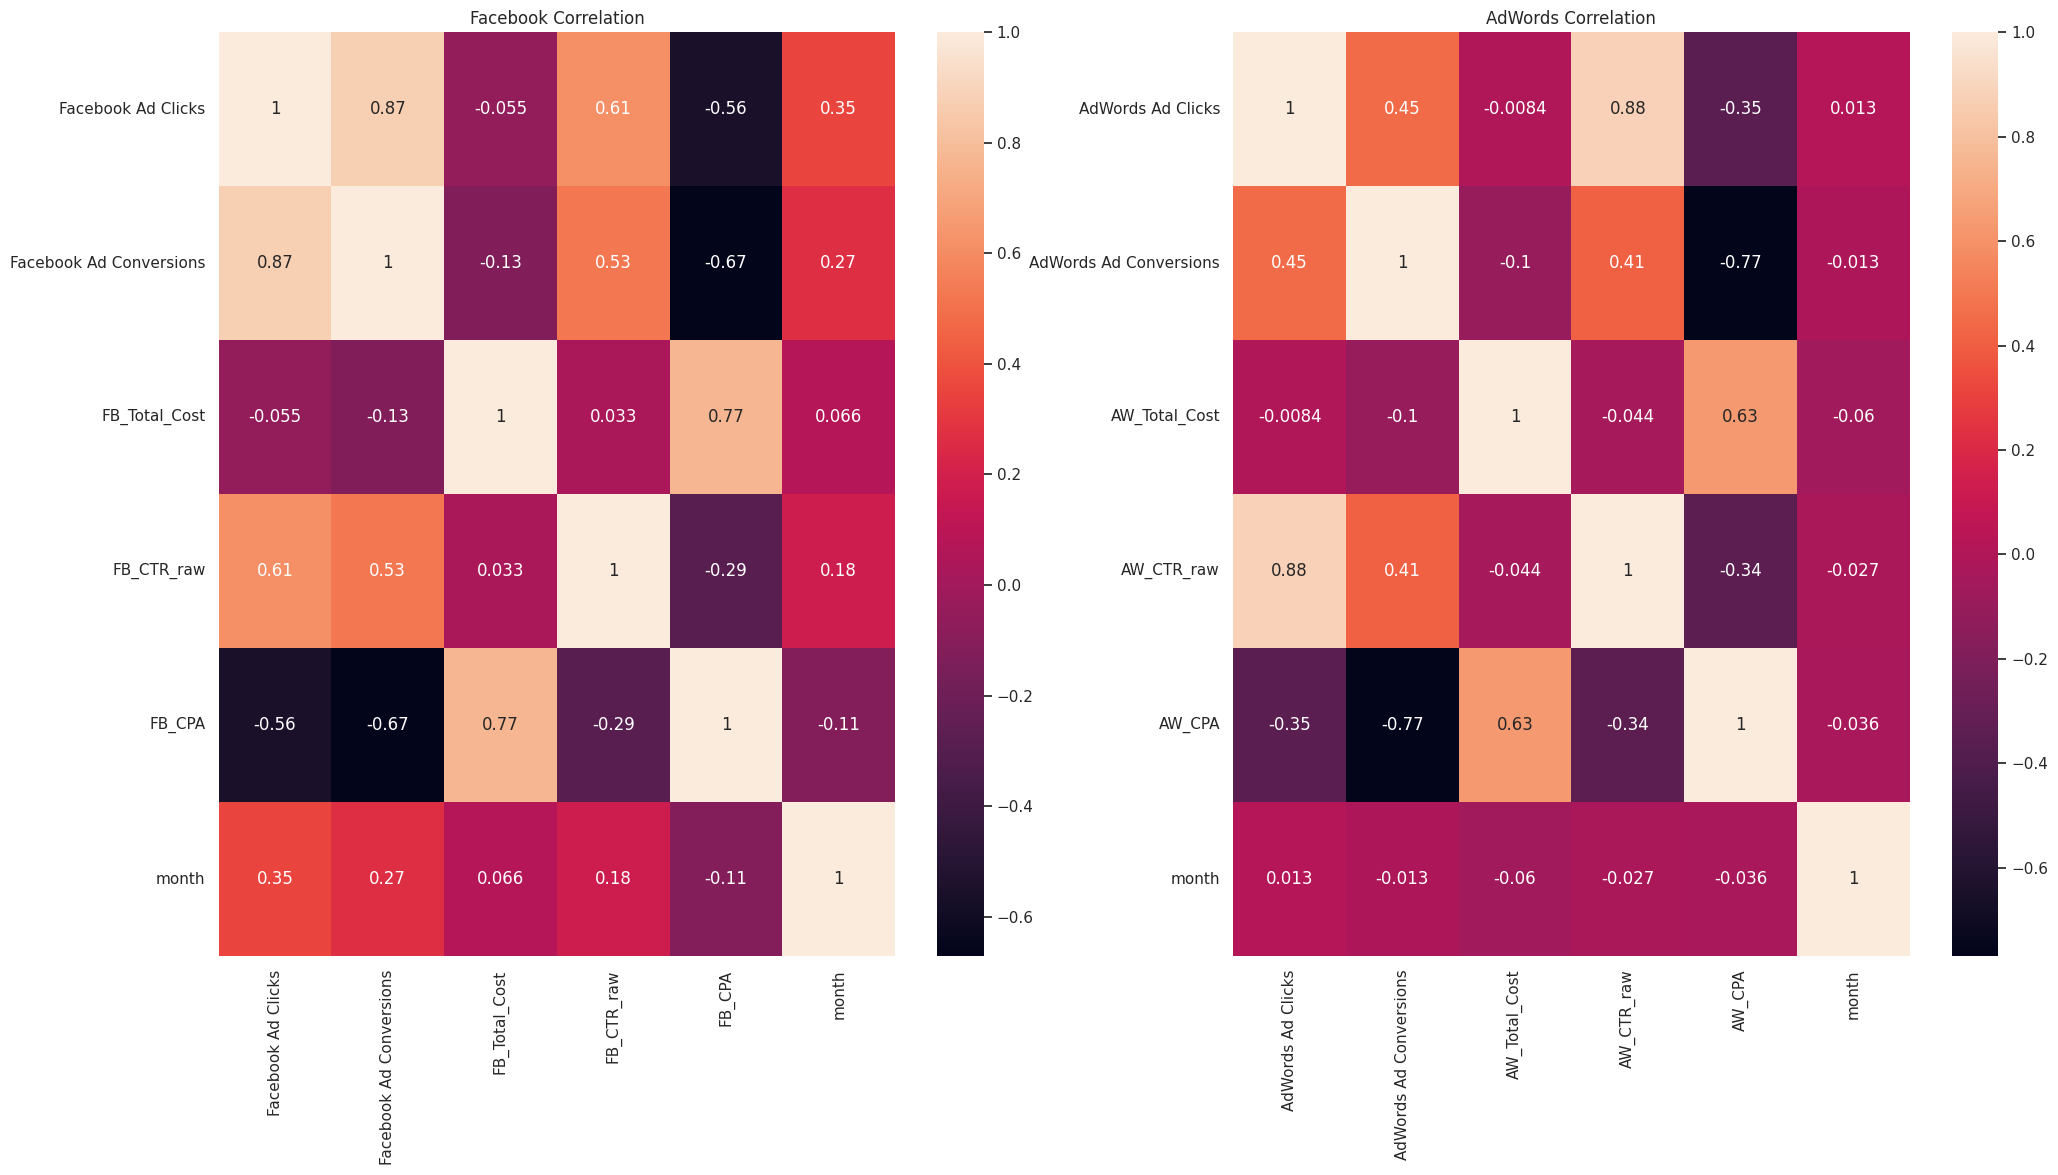

In [124]:
# Correlation Plot

plt.figure(figsize=(24,12))

plt.subplot(1,2,1)
sns.heatmap(fb_corr, annot=True)
plt.title("Facebook Correlation")

plt.subplot(1,2,2)
sns.heatmap(aw_corr, annot=True)
plt.title("AdWords Correlation")

plt.show()

###Observation
Key Differences:
Facebook's conversions are more strongly driven by clicks, and its performance shows some monthly seasonality.

AdWords' conversions have a weaker relationship with clicks, but its CTR is highly effective in driving clicks. AdWords also does not show a clear monthly trend.

------
Facebook Correlation:

Strong Positive Correlation: There's a very strong positive correlation between 'Facebook Ad Clicks' and 'Facebook Ad Conversions' (0.87). This indicates that as clicks increase, conversions also tend to increase significantly.

Moderate Positive Correlation: 'FB_CTR_raw' (Click-Through Rate) has a moderate positive correlation with both 'Facebook Ad Clicks' (0.61) and 'Facebook Ad Conversions' (0.53), suggesting that a higher CTR generally leads to more clicks and conversions.

Strong Negative Correlation: 'FB_CPA' (Cost Per Acquisition) shows a strong negative correlation with 'Facebook Ad Conversions' (-0.67) and 'Facebook Ad Clicks' (-0.56). This makes intuitive sense: as conversions/clicks increase, the cost per acquisition tends to decrease.

Positive Correlation with Month: 'month' has a positive correlation with 'Facebook Ad Clicks' (0.35) and 'Facebook Ad Conversions' (0.27), which might suggest seasonal trends or improved performance towards the end of the year.

AdWords Correlation:

Weaker Positive Correlation for Conversions: Unlike Facebook, the correlation between 'AdWords Ad Clicks' and 'AdWords Ad Conversions' is much weaker (0.45). This indicates that a higher number of clicks on AdWords does not translate into conversions as directly or reliably as on Facebook.

Strong Positive Correlation for CTR: 'AW_CTR_raw' has a very strong positive correlation with 'AdWords Ad Clicks' (0.88), meaning a higher CTR is highly effective in driving more clicks on AdWords.


Strong Negative Correlation for CPA: Similar to Facebook, 'AW_CPA' shows a strong negative correlation with 'AdWords Ad Conversions' (-0.77), indicating that more conversions lead to a lower CPA.


No Significant Monthly Trend: The 'month' correlation with AdWords metrics (e.g., 'AdWords Ad Clicks', 'AdWords Ad Conversions') is very close to zero, suggesting no strong seasonal pattern or trend over the year for AdWords performance.



###Statistical Testing


In [125]:

fb_cr = df['FB_CR_calc'].dropna()
aw_cr = df['AW_CR_calc'].dropna()

fb_norm = stats.shapiro(fb_cr)
aw_norm = stats.shapiro(aw_cr)

alpha = 0.05

if fb_norm.pvalue > alpha and aw_norm.pvalue > alpha:
    stat, p = stats.ttest_ind(fb_cr, aw_cr, equal_var=False)
    test = "t-test"
else:
    stat, p = stats.mannwhitneyu(fb_cr, aw_cr)
    test = "Mann-Whitney"

print("Test:", test)
print("p-value:", p)

Test: Mann-Whitney
p-value: 6.701156302238753e-121


###Observation
The Mann-Whitney U test indicates a statistically significant difference
between Facebook and AdWords conversion rates (p-value ≈ 0), confirming that
the platforms do not perform equally.

To quantify this difference, confidence intervals are calculated:

###Confidence Intervals for Mean Differences





In [126]:

# --- CR Confidence Interval ---
mean_fb = fb_cr.mean()
mean_aw = aw_cr.mean()
diff = mean_fb - mean_aw

n1, n2 = len(fb_cr), len(aw_cr)
var1, var2 = fb_cr.var(ddof=1), aw_cr.var(ddof=1)

se = np.sqrt((var1/n1) + (var2/n2))
df_w = ((var1/n1 + var2/n2)**2)/(((var1/n1)**2)/(n1-1)+((var2/n2)**2)/(n2-1))
t_crit = stats.t.ppf(0.975, df_w)

margin = t_crit * se
ci_low = diff - margin
ci_high = diff + margin

print("CR Difference:", diff)
print("95% CI for CR:", ci_low, ci_high)


# --- CPA Confidence Interval ---
fb_cpa = df['FB_CPA'].replace([np.inf,-np.inf],np.nan).dropna()
aw_cpa = df['AW_CPA'].replace([np.inf,-np.inf],np.nan).dropna()

mean_fb_cpa = fb_cpa.mean()
mean_aw_cpa = aw_cpa.mean()
diff_cpa = mean_fb_cpa - mean_aw_cpa

n1, n2 = len(fb_cpa), len(aw_cpa)
var1, var2 = fb_cpa.var(ddof=1), aw_cpa.var(ddof=1)

# CORRECTED MATH: Applying Welch-Satterthwaite to CPA
se_cpa = np.sqrt((var1/n1) + (var2/n2))
df_w_cpa = ((var1/n1 + var2/n2)**2)/(((var1/n1)**2)/(n1-1)+((var2/n2)**2)/(n2-1))
t_crit_cpa = stats.t.ppf(0.975, df_w_cpa)

margin_cpa = t_crit_cpa * se_cpa

ci_low_cpa = diff_cpa - margin_cpa
ci_high_cpa = diff_cpa + margin_cpa

print("CPA Difference:", diff_cpa)
print("95% CI for CPA:", ci_low_cpa, ci_high_cpa)

CR Difference: 0.16973456493402098
95% CI for CR: 0.1644147269367199 0.17505440293132205
CPA Difference: -16.642878989704663
95% CI for CPA: -17.76018616256956 -15.525571816839763


####Observation
The analysis reveals a clear and statistically robust advantage for Facebook Ads:

1. Conversion Efficiency:
Facebook shows a significantly higher conversion rate than AdWords
(Δ = +0.1697, 95% CI: [0.1644, 0.1750]), indicating stronger user engagement
and funnel performance.

2. Cost Efficiency:
Facebook also demonstrates significantly lower cost per acquisition
(Δ = -16.64, 95% CI: [-17.76, -15.53]), making it more cost-effective.

Conclusion:
Since both confidence intervals exclude 0, the results are statistically
significant and practically meaningful.

Business Implication:
Facebook outperforms AdWords on both effectiveness (CR) and efficiency (CPA),
making it the preferred platform for budget allocation and scaling.


###Predictive Modeling & Assumption Validation

R2: 0.7752285038622598
MSE: 2.186386803114262


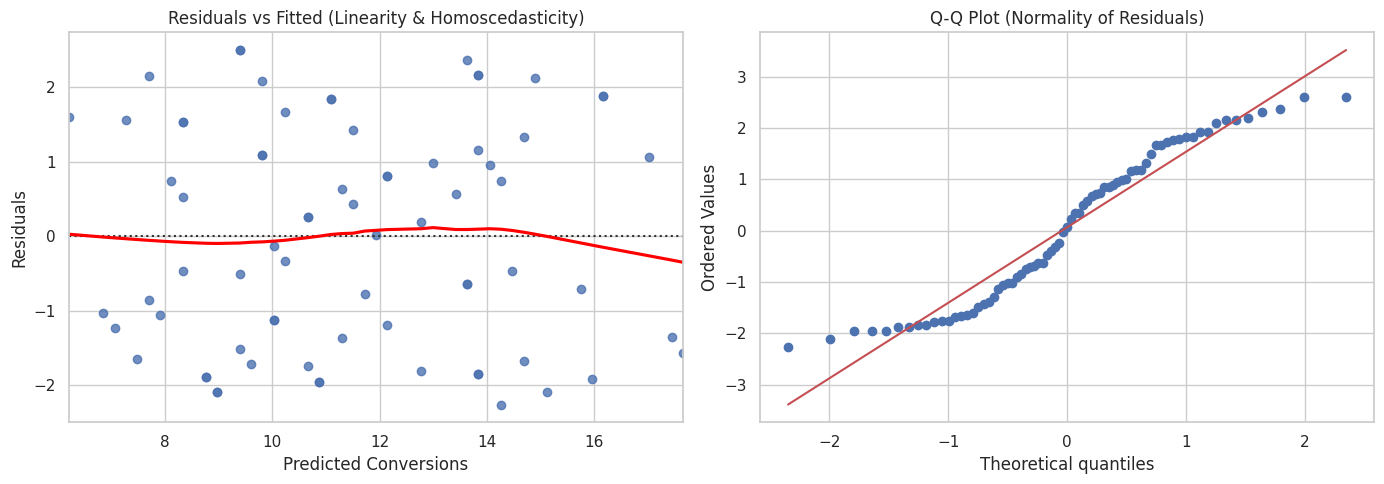

Shapiro-Wilk Test for Normality p-value: 0.0005


In [127]:
X = df[['Facebook Ad Clicks']]
y = df['Facebook Ad Conversions']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test,pred))
print("MSE:", mean_squared_error(y_test,pred))


#RESIDUAL ANALYSIS
residuals = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Test for Linearity & Homoscedasticity (Residuals vs. Fitted)
sns.residplot(x=pred, y=residuals, lowess=True, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title('Residuals vs Fitted (Linearity & Homoscedasticity)')
axes[0].set_xlabel('Predicted Conversions')
axes[0].set_ylabel('Residuals')


# 2. Test for Normality (QQ Plot)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality of Residuals)')

plt.tight_layout()
plt.show()

#Statistical test for Normality
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Normality p-value: {shapiro_test.pvalue:.4f}")

###Assessment of Your Results
Linearity & Homoscedasticity(Left plot):
The Residuals vs Fitted plot.
The points are fairly randomly scattered around the zero line, and the red trend line is mostly flat.

We do not see a "megaphone" or funnel shape (which would indicate heteroscedasticity), nor do we see a strong "U" or "bow" shape (which would indicate non-linearity).

The assumptions of Linearity and Homoscedasticity are generally satisfied.

Normality (Right Plot & P-value)
The Q-Q Plot. The blue dots track the red line well in the middle, but they peel away significantly at the bottom-left and top-right corners. This "S-shape" indicates that your errors have heavy tails (outliers).

Shapiro-Wilk p-value is 0.0005. Because this is well below the standard 0.05 threshold, we must reject the null hypothesis.

Conclusion: The assumption of Normality is statistically violated.


###Business Application

In [128]:
intercept = model.intercept_
coefficient = model.coef_[0]

target_conversions = int(input())

required_clicks = (target_conversions - intercept) / coefficient

print("Required Clicks:", required_clicks)

50
Required Clicks: 224.66436795516296


### Final Business Insights

In [129]:
print("\n--- FINAL INSIGHTS ---")

if ci_low > 0:
    print("Facebook has better conversion efficiency")
elif ci_high < 0:
    print("AdWords has better conversion efficiency")
else:
    print("No clear winner in CR")

if ci_high_cpa < 0:
    print("Facebook is more cost-efficient")
elif ci_low_cpa > 0:
    print("AdWords is more cost-efficient")
else:
    print("No clear winner in CPA")


--- FINAL INSIGHTS ---
Facebook has better conversion efficiency
Facebook is more cost-efficient


###Strategic Recommendations

1. Budget Reallocation (CPA-Driven):
Based on the results and confidence intervals, Facebook demonstrates
lower cost per acquisition (CPA) compared to AdWords.

Recommendation:
Reallocate approximately 15–20% of the daily ad budget toward Facebook campaigns
to improve overall cost efficiency and return on ad spend (ROAS).

Note:
This shift should be monitored incrementally to validate sustained performance
and avoid over-allocation risks.

---
2. Funnel Optimization (Conversion Efficiency):
Analysis of the click-to-conversion relationship indicates variability in
conversion efficiency across days.

Recommendation:
Conduct funnel diagnostics to identify drop-offs between:
- Ad Views to Clicks (CTR issues: creative/targeting)
- Clicks to Conversions (landing page or intent mismatch)

Focus Areas:
- A/B test ad creatives
- Optimize landing page experience
- Improve audience targeting

----
3. Target-Based Campaign Planning (Predictive Scaling):
The regression model provides a way to estimate conversions from clicks
and reverse-calculate required traffic.

Recommendation:
Use the model to set campaign targets by estimating the number of clicks
required to achieve specific conversion goals (e.g., monthly or quarterly targets).

Application:
- Forecast required traffic for revenue goals
- Align budget allocation with expected performance
- Support campaign scaling decisions

Note:
These estimates assume linear behavior and should be treated as directional
guidance rather than exact forecasts.

###Model Limitations & Assumptions:
1. Linear Assumption:
The reverse prediction (target conversions to required clicks) assumes a linear relationship
between clicks and conversions. In practice, this may not hold at higher volumes due to
saturation effects.

2. External Factors:
The model does not account for external variables such as audience quality, ad creatives,
budget constraints, or seasonality, which can influence conversion outcomes.

3. Residual Behavior:
Model diagnostics indicate slight non-linearity and deviations from normality, which is
common in real-world marketing data.

Strategic Justification:
Despite these limitations, linear regression serves as a strong baseline due to its
interpretability and ability to provide directional insights for decision-making.

Next Steps:
Future improvements could include:
- Log transformations to handle skewness
- Non-linear models (e.g., Random Forest) to capture complex relationships
- Incorporating additional features for better prediction accuracy
